In [1]:
#https://www.novoco.com/public-media/documents/hud-median-family-income-states-metro-nonmetro-fy-2024-04012024.pdf

In [ ]:
#comparing 2024 Ev sale and 2024 Median Income

In [ ]:
#EV Registration by state for 2024 for -https://afdc.energy.gov/data/10962

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
income_per_state_df = pd.read_excel("C:/Users/nainy/Documents/nss_dda16/python/projects/EV_Capstone_project_nainy/data/hud-median-family-income-states-metro-nonmetro-fy-2024-04012024.xlsx")

In [4]:
income_per_state_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   State           53 non-null     object 
 1   TOTAL           52 non-null     float64
 2   FY  2024 METRO  52 non-null     float64
 3   NONMETRO        52 non-null     object 
dtypes: float64(2), object(2)
memory usage: 1.8+ KB


In [5]:
modified_income_per_state_df = income_per_state_df[['State','TOTAL']]

In [6]:
Ev_sales_by_states= pd.read_excel("C:/Users/nainy/Documents/nss_dda16/python/projects/EV_Capstone_project_nainy/data/2024_EV_car_sales_NOT _PHEV.xlsx")

In [7]:
Ev_sales_by_states.shape

(51, 2)

In [8]:
Ev_sales_by_states.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   State               51 non-null     object
 1   Registration Count  51 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 948.0+ bytes


In [9]:
Ev_sales_by_states.sort_values(by =   'Registration Count' , ascending = False)

,State,Registration Count
4,California,1256646
9,Florida,254878
43,Texas,230125
47,Washington,152101
30,New Jersey,134753
32,New York,131250
13,Illinois,99573
10,Georgia,92368
5,Colorado,90083
2,Arizona,89798


In [10]:
modified_income_per_state_df = income_per_state_df.rename(columns ={'TOTAL':'Median_house_hold_income'})
modified_income_per_state_df

,State,Median_house_hold_income,FY 2024 METRO,NONMETRO
0,Alabama,82500.0,88000.0,66100
1,Alaska,111800.0,114000.0,101300
2,Arizona,94200.0,95700.0,66100
3,Arkansas,75100.0,82700.0,65200
4,California,111300.0,111900.0,87900
5,Colorado,116400.0,120500.0,94200
6,Connecticut,122300.0,122900.0,114200
7,Delaware,106300.0,106300.0,77400*
8,District of Columbia,155500.0,155500.0,77400*
9,Florida,88600.0,89300.0,65200


In [38]:
Ev_sales_by_states.head(3)
Ev_sales_by_states= Ev_sales_by_states.rename(columns ={'Registration Count': 'Vehicle Registration Count '})

In [30]:
modified_income_per_state_df= modified_income_per_state_df[['State','Median_house_hold_income']]
modified_income_per_state_df

,State,Median_house_hold_income
0,Alabama,82500.0
1,Alaska,111800.0
2,Arizona,94200.0
3,Arkansas,75100.0
4,California,111300.0
5,Colorado,116400.0
6,Connecticut,122300.0
7,Delaware,106300.0
8,District of Columbia,155500.0
9,Florida,88600.0


In [42]:
Ev_sales_by_states_and_income_per_state_df = pd.merge(modified_income_per_state_df,Ev_sales_by_states, how ='inner')

<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, Median_house_hold_income to Vehicle Registration Count 
Data columns (total 2 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Median_house_hold_income     2 non-null      float64
 1   Vehicle Registration Count   2 non-null      float64
dtypes: float64(2)
memory usage: 156.0+ bytes


In [60]:
ev_median_df= Ev_sales_by_states_and_income_per_state_df.corr(numeric_only = True)
ev_median_df

,Median_house_hold_income,Vehicle Registration Count
Median_house_hold_income,1.000000,0.203896
Vehicle Registration Count,0.203896,1.000000


In [68]:
ev_median_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, Median_house_hold_income to Vehicle Registration Count 
Data columns (total 2 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Median_house_hold_income     2 non-null      float64
 1   Vehicle Registration Count   2 non-null      float64
dtypes: float64(2)
memory usage: 156.0+ bytes


                             Median_house_hold_income  \
Median_house_hold_income                     1.000000   
Vehicle Registration Count                   0.203896   

                             Vehicle Registration Count   
Median_house_hold_income                        0.203896  
Vehicle Registration Count                      1.000000  


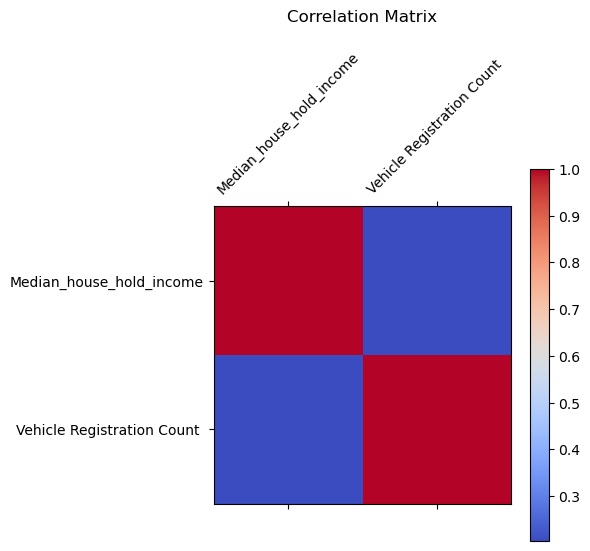

In [72]:

print(ev_median_df)

# Optional: visualize it
import matplotlib.pyplot as plt

plt.matshow(ev_median_df, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(ev_median_df.columns)), ev_median_df.columns, rotation=45)
plt.yticks(range(len(ev_median_df.columns)), ev_median_df.columns)
plt.title("Correlation Matrix", pad=20)
plt.show()

# 0.203896 falls in the weak zone.

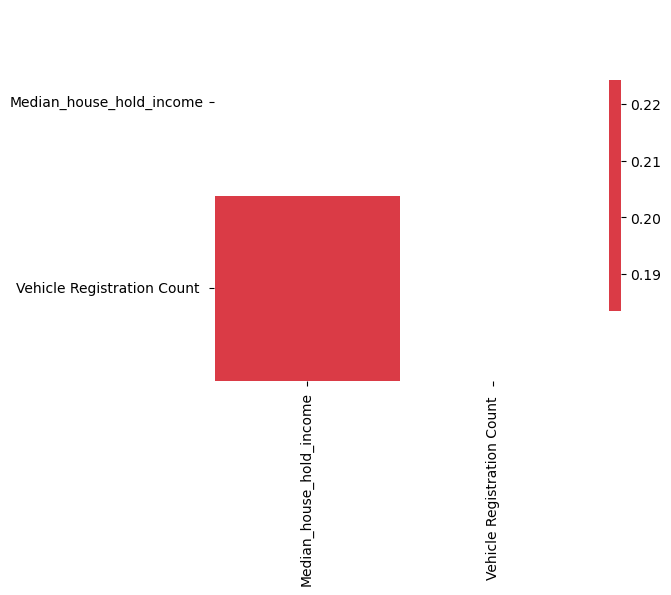

In [64]:
fig, ax = plt.subplots(figsize=(6, 6))


# create a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Generate a mask for the upper triangle
mask = np.zeros_like(ev_median_df, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(ev_median_df, cmap=cmap, mask = mask, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5});

🔹 How to read this:

Diagonal values (1.0):

Any variable correlated with itself will always be 1 (perfect correlation).

Example: Median_house_hold_income ↔ Median_house_hold_income = 1.0

Correlation between different variables (0.203896):

The correlation between Median_house_hold_income and Vehicle Registration Count is ≈ 0.20.

🔹 What does 0.20 mean?

Correlation values range from -1 to +1:

+1.0 → Perfect positive correlation (as one increases, the other always increases).

-1.0 → Perfect negative correlation (as one increases, the other always decreases).

0.0 → No correlation (no relationship).

So:

0.20 (≈20%) means a weak positive correlation.

Households with higher median income tend to have slightly more vehicle registrations, but the relationship is not strong.

Other factors (population size, urban/rural area, number of households, policies, etc.) probably play a bigger role.

🔹 Rule of thumb for correlation strength:

0.0 – 0.19 → Very weak

0.20 – 0.39 → Weak

0.40 – 0.59 → Moderate

0.60 – 0.79 → Strong

0.80 – 1.0 → Very strong
Your 0.203896 falls in the weak zone.